In [35]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


# 1. Data Loading 

In [36]:
data_path = 'data/'
try:
    train_df = pd.read_csv(data_path + 'train.csv')
    test_df = pd.read_csv(data_path + 'test.csv')
    sample_submission_df = pd.read_csv(data_path + 'sample_submission.csv')
except FileNotFoundError as e:
    train_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
    test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
    sample_submission_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv')

print("Train data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

Train data shape: (630000, 21)
Test data shape: (270000, 20)


# 2. Data Cleaning & Quality Check

In [37]:
print(f"Total missing values: {train_df.isnull().sum().sum()}")
print(f"Total duplicate rows: {train_df.duplicated().sum()}")
train_df.describe()

Total missing values: 0
Total duplicate rows: 0


,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


# 3. Feature Engineering

We use 'Group-by Aggregations' to capture how specific conditions (Rain, Temp, Moisture) differ from the norm for each crop. This 'relative' context is often much more predictive than simple mathematical combinations.

In [38]:
def create_features(df, train_source=None):
    # If train_source is provided, we use it to calculate means to avoid data leakage in test set
    source_df = train_source if train_source is not None else df
    
    # 1. Crop-Specific Means (Aggregations)
    crop_stats = source_df.groupby('Crop_Type')[['Rainfall_mm', 'Temperature_C', 'Soil_Moisture']].mean().reset_index()
    crop_stats.columns = ['Crop_Type', 'Crop_Avg_Rain', 'Crop_Avg_Temp', 'Crop_Avg_Moisture']
    
    # Merge stats back to dataframe
    df = df.merge(crop_stats, on='Crop_Type', how='left')
    
    # 2. Deviation Features (Relative differences)
    df['Rainfall_Deviation'] = df['Rainfall_mm'] - df['Crop_Avg_Rain']
    df['Temperature_Deviation'] = df['Temperature_C'] - df['Crop_Avg_Temp']
    df['Moisture_Deviation'] = df['Soil_Moisture'] - df['Crop_Avg_Moisture']
    
    # 3. Simple high-impact interaction
    # Evapotranspiration proxy (Non-linear)
    df['Water_Stress_Index'] = (df['Temperature_C'] * df['Wind_Speed_kmh']) / (df['Humidity'] + 1)
    
    # Drop the raw mean columns to keep the feature set lean
    df.drop(['Crop_Avg_Rain', 'Crop_Avg_Temp', 'Crop_Avg_Moisture'], axis=1, inplace=True)
    
    return df

# Apply features (passing train_df to create_features for test_df to prevent leakage)
train_df = create_features(train_df)
test_df = create_features(test_df, train_source=train_df)
print("Relative features added. Shape:", train_df.shape)

Relative features added. Shape: (630000, 25)


### 3.1 Feature Correlation Analysis

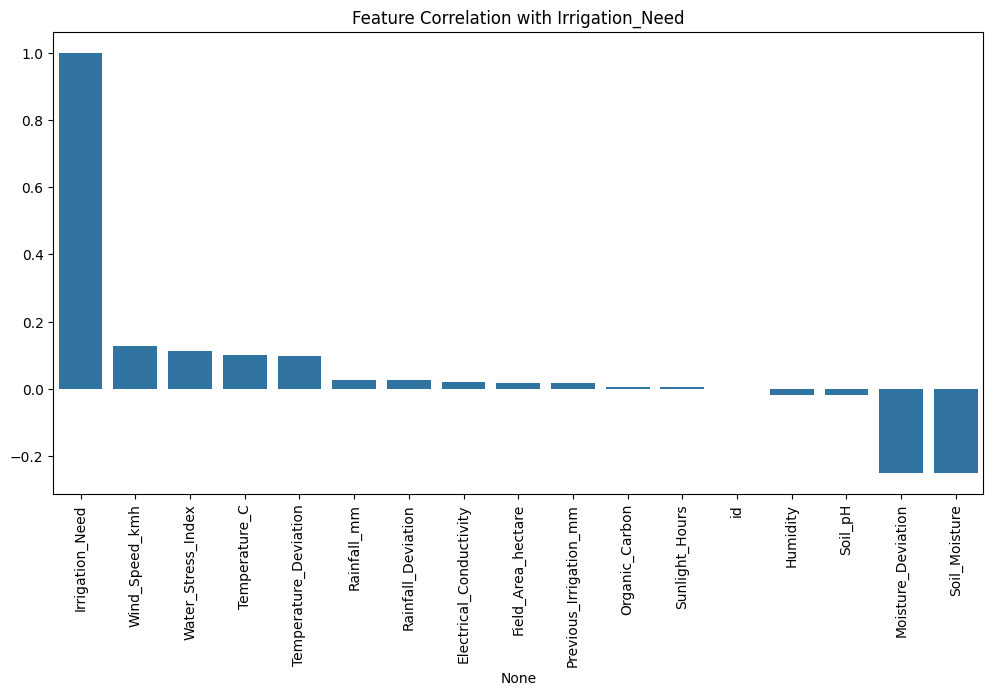

Features with > 0.9 correlation with another feature:
['Rainfall_Deviation', 'Temperature_Deviation', 'Moisture_Deviation']


In [39]:
def analyze_correlation(df, target_col):
    temp_df = df.copy()
    le = LabelEncoder()
    if temp_df[target_col].dtype == 'object':
        temp_df[target_col] = le.fit_transform(temp_df[target_col])
    corr_matrix = temp_df.select_dtypes(include=[np.number]).corr()
    plt.figure(figsize=(12, 6))
    target_corr = corr_matrix[target_col].sort_values(ascending=False)
    sns.barplot(x=target_corr.index, y=target_corr.values)
    plt.title(f'Feature Correlation with {target_col}')
    plt.xticks(rotation=90)
    plt.show()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
    print("Features with > 0.9 correlation with another feature:")
    print(to_drop)
    return target_corr

target_correlations = analyze_correlation(train_df, 'Irrigation_Need')

# 4. Data Preprocessing

In [40]:
X = train_df.drop('Irrigation_Need', axis=1)
y = train_df['Irrigation_Need']

categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['number']).columns

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    test_df[col] = le.transform(test_df[col])

scaler = StandardScaler()
numerical_features_no_id = [col for col in numerical_features if col != 'id']
X[numerical_features_no_id] = scaler.fit_transform(X[numerical_features_no_id])
test_df[numerical_features_no_id] = scaler.transform(test_df[numerical_features_no_id])

# 5. Model Training

In [41]:
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=0.1, stratify=y, random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50],
}
lgbm = lgb.LGBMClassifier(random_state=42, class_weight='balanced', force_row_wise=True)
grid_search = GridSearchCV(estimator=lgbm, param_grid=param_grid, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_search.fit(X_sample, y_sample)
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Total Bins 3980
[LightGBM] [Info] Number of data points in the train set: 63000, number of used features: 24
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Best parameters found:  {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 50}


In [42]:
model = lgb.LGBMClassifier(random_state=42, class_weight='balanced', force_row_wise=True, **best_params)
model.fit(X, y)

[LightGBM] [Info] Total Bins 3980
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 24
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


LGBMClassifier(class_weight='balanced', force_row_wise=True, n_estimators=200,
               num_leaves=50, random_state=42)

## 5.4 Feature Importance Analysis

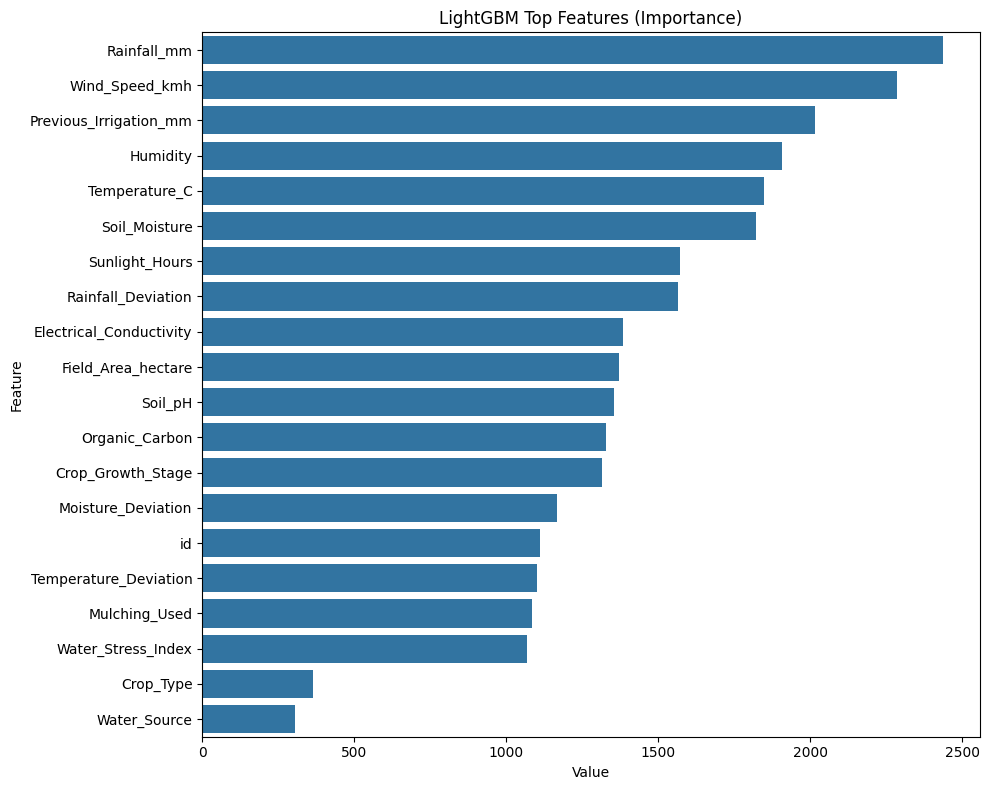

In [43]:
feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': X.columns})
plt.figure(figsize=(10, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).head(20))
plt.title('LightGBM Top Features (Importance)')
plt.tight_layout()
plt.show()

# 6. Prediction and Submission

In [44]:
test_predictions = model.predict(test_df)
submission_df = pd.DataFrame({'id': test_df['id'], 'Irrigation_Need': test_predictions})
submission_df.to_csv('submission.csv', index=False)
print("Submission file created successfully!")

Submission file created successfully!
